In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [ ]:
df = pd.read_csv("bank.csv", sep=";")
df.info()
display(df.head(), df.describe())
print("\nMissing values per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000



Missing values per column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

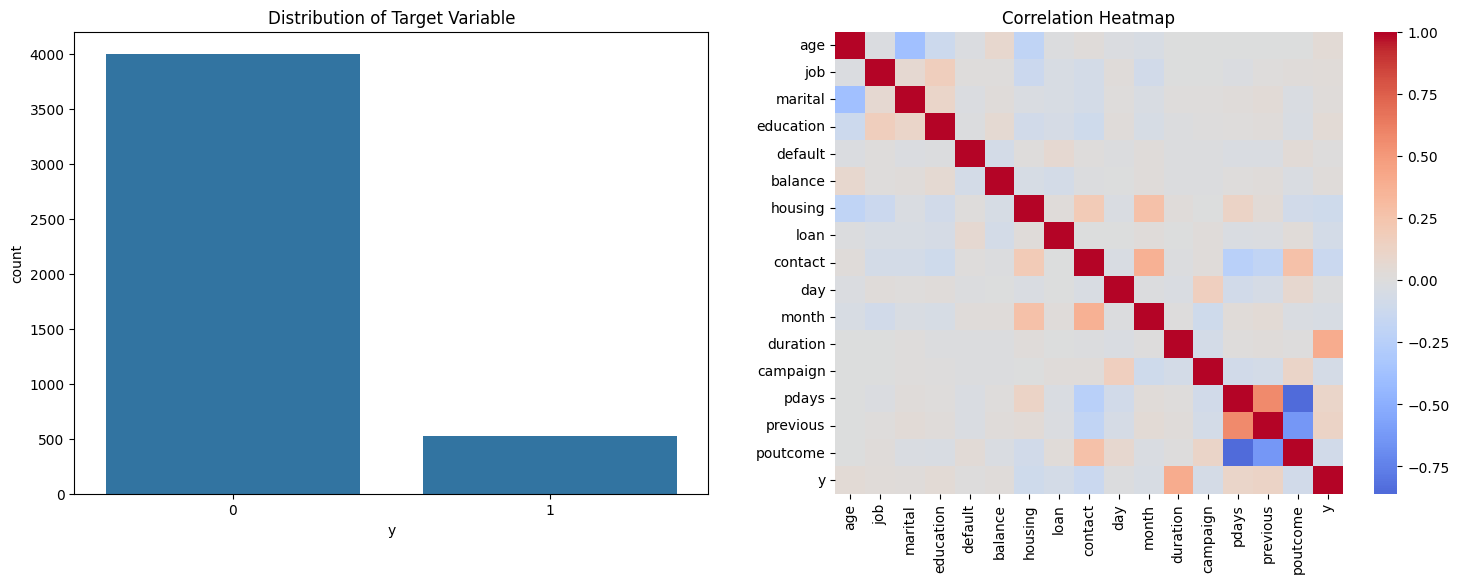

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x="y", data=df, ax=axes[0]).set_title(
    "Distribution of Target Variable"
)
sns.heatmap(df.corr(), cmap="coolwarm", center=0, ax=axes[1]).set_title(
    "Correlation Heatmap"
)
plt.show()


In [ ]:
X, y = df.drop("y", axis=1), df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n--- Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nFeature Importances:")
fi = (
    pd.DataFrame({"feature": X.columns, "importance": clf.feature_importances_})
    .sort_values(by="importance", ascending=False)
    .head(5))
for _ , row in fi.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")


--- Model Evaluation ---
Accuracy: 0.8983425414364641

Confusion Matrix:
 [[781  26]
 [ 66  32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       807
           1       0.55      0.33      0.41        98

    accuracy                           0.90       905
   macro avg       0.74      0.65      0.68       905
weighted avg       0.88      0.90      0.89       905


Feature Importances:
duration: 0.4903
pdays: 0.1344
poutcome: 0.1143
age: 0.0985
month: 0.0519


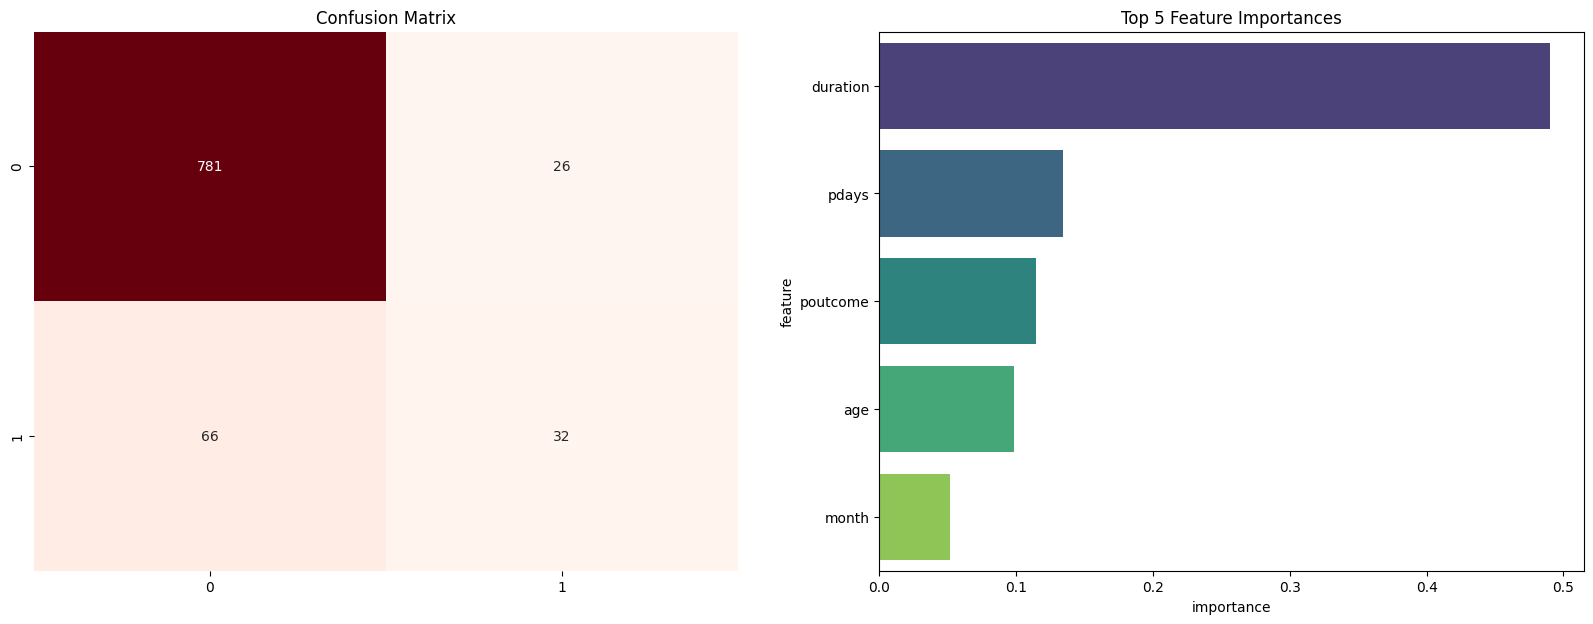

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    ax=axes[0],).set_title("Confusion Matrix")
sns.barplot(
    x="importance",
    y="feature",
    data=fi,
    palette="viridis",
    hue="feature",
    legend=False,
    ax=axes[1],).set_title("Top 5 Feature Importances")
plt.show()

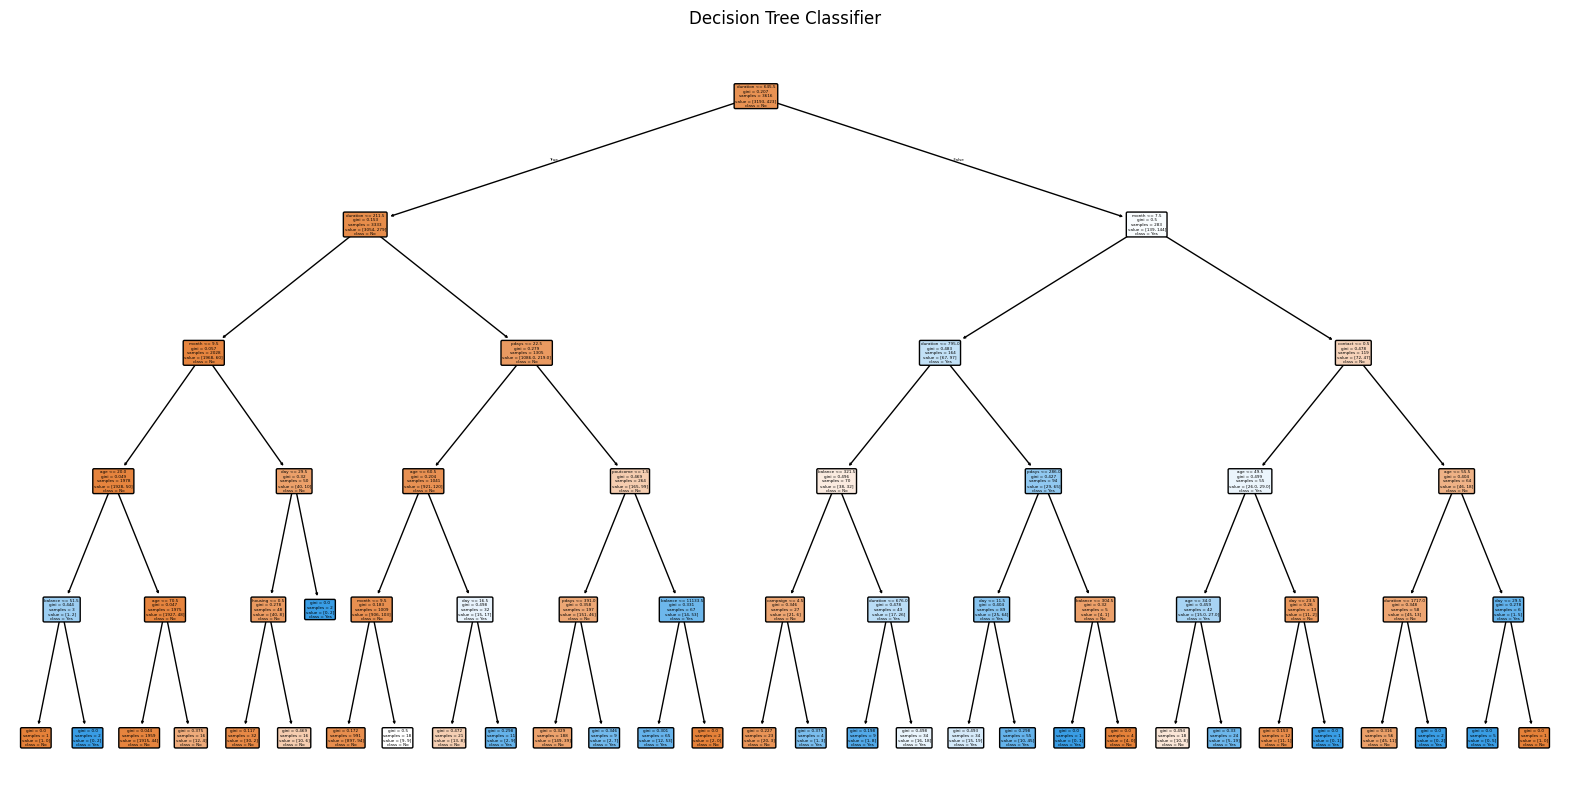

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
)
plt.title("Decision Tree Classifier")
plt.show()